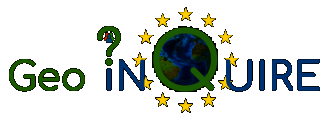

# EFSM20 Fault Explorer - 3D Mesh Annotator - 3D Mesh Thinner

This notebook connects to the **European Fault Source Model 2020 (EFSM20 & EFSM20 Meshes)** OGC WFS services, lets you explore crustal faults on an interactive map, download 3D mesh GeoJSON files, enrich them with attributes from the fault source model, and thin the 3D mesh by splitting its triangles to a maximum area threshold.

**Services used:**
- `EFSM20` — fault source parameters: `https://services.seismofaults.eu/EFSM20/ows`
- `EFSM20_Meshes` — 3D fault meshes: `https://services.seismofaults.eu/EFSM20_Meshes/ows`

Basili, R., Danciu, L., Beauval, C., Sesetyan, K., Vilanova, S. P., Adamia, S., Arroucau, P., Atanackov, J., Baize, S., Canora, C., Caputo, R., Carafa, M. M. C., Cushing, E. M., Custódio, S., Demircioglu Tumsa, M. B., Duarte, J. C., Ganas, A., García-Mayordomo, J., Gómez de la Peña, L., Gràcia, E., Jamšek Rupnik, P., Jomard, H., Kastelic, V., Maesano, F. E., Martín-Banda, R., Martínez-Loriente, S., Neres, M., Perea, H., Šket Motnikar, B., Tiberti, M. M., Tsereteli, N., Tsironi, V., Vallone, R., Vanneste, K., Zupančič, P., and Giardini, D. (2024). The European Fault-Source Model 2020 (EFSM20): geologic input data for the European Seismic Hazard Model 2020, Nat. Hazards Earth Syst. Sci., https://doi.org/10.5194/nhess-24-3945-2024

Basili R., Danciu L., Beauval C., Sesetyan K., Vilanova S., Adamia S., Arroucau P., Atanackov J., Baize S., Canora C., Caputo R., Carafa M., Cushing M., Custódio S., Demircioglu Tumsa M., Duarte J., Ganas A., García-Mayordomo J., Gómez de la Peña L., Gràcia E., Jamšek Rupnik P., Jomard H., Kastelic V., Maesano F. E., Martín-Banda R., Martínez-Loriente S., Neres M., Perea H., Sket-Motnikar B., Tiberti M. M., Tsereteli N., Tsironi V., Vallone R., Vanneste K., Zupančič P. (2022). European Fault-Source Model 2020 (EFSM20): online data on fault geometry and activity parameters [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/efsm20

Basili R., Taccone R., Vallone R., Maesano F. E. (2024). European Fault-Source Model 2020 (EFSM20): 3D triangular meshes [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/efsm20/meshes

See https://seismofaults.eu/efsm20 for more details.

---
## 0. Install dependencies (run if needed)

In [1]:
# Uncomment and run if needed
# !pip install ipyleaflet owslib requests geopandas shapely ipywidgets "pyvista[jupyter]" trame

---
## Quick reference — typical workflow

| Step | Cell | What happens |
|------|------|--------------|
| 1 | `Connect` | OWSLib connects to both WFS services and prints available layers |
| 2 | `Map` | Interactive map with Google Hybrid background, CF-top traces (blue) and CF-polygons (orange) |
| 3 | `Select fault` | Click on a polygon on the map |
| 4 | `Download mesh` | Fetches the 3D mesh GeoJSON for the chosen fault |
| 5 | `Match` | Finds the same fault in the CF-top layer using the IDFS attribute |
| 6–7 | `Add attributes` | Multi-select widget lets you append any CF-top attribute value to every triangle row; repeat as desired |
| 8 | `Download` | Generates an in-browser download link for the final enriched GeoJSON |
| 9 | `Mesh thinning` | Triangle thinning — split large triangles to a maximum area threshold & download |
| 10 | `Visualise` | Visualise thinned mesh on an interactive map |

> **Tip:** If the automatic column detection picks the wrong name, inspect `gdf_cf_top.columns` and `gdf_cf_poly.columns` in a new cell and update the relevant variables (`LAYER_CF_TOP`, `LAYER_CF_POLY`, `label_col_poly`, etc.).

## 1. Connect to WFS services & fetch layers

In [2]:
import requests
import json
import geopandas as gpd
import pandas as pd
import numpy as np
from owslib.wfs import WebFeatureService
import warnings
warnings.filterwarnings('ignore')

# ── WFS endpoints ──────────────────────────────────────────────────────────────
WFS_PARAMS_URL  = "https://services.seismofaults.eu/EFSM20/ows"
WFS_MESHES_URL  = "https://services.seismofaults.eu/EFSM20_Meshes/ows"

# Layer names
LAYER_CF_TOP    = "efsm20_cf_top"               # Crustal Faults – top traces (EFSM20)
LAYER_CF_POLY   = "efsm20_cf_polygons"          # Crustal Faults – polygons (EFSM20_Meshes)
                                                 # NOTE: intentionally NOT efsm20_cf_meshes (too many records)

print("Connecting to WFS services ...")
wfs_params = WebFeatureService(WFS_PARAMS_URL,  version="2.0.0")
wfs_meshes = WebFeatureService(WFS_MESHES_URL,  version="2.0.0")

print("\n── EFSM20 layers (fault parameters) ──")
for name, layer in wfs_params.contents.items():
    print(f"  {name:45s}  {layer.title}")

print("\n── EFSM20_Meshes layers ──")
for name, layer in wfs_meshes.contents.items():
    print(f"  {name:45s}  {layer.title}")

Connecting to WFS services ...

── EFSM20 layers (fault parameters) ──
  EFSM20:efsm20_cf_ctb                           EFSM20_CFDepths
  EFSM20:efsm20_cf_bot                           EFSM20_CF_BOT
  EFSM20:efsm20_cf_mid                           EFSM20_CF_MID
  EFSM20:efsm20_cf_pld                           EFSM20_CF_PLD
  EFSM20:efsm20_cf_top                           EFSM20_CF_TOP
  EFSM20:efsm20_is_lattice                       EFSM20_IS_Lattice
  EFSM20:efsm20_si_discretization                EFSM20_SI_Discretization
  EFSM20:efsm20_si_parameters                    EFSM20_SI_Parameters
  EFSM20:efsm20_si_realizations                  EFSM20_SI_Realizations
  EFSM20:efsm20_slabdepths                       EFSM20_SlabDepths

── EFSM20_Meshes layers ──
  EFSM20_Meshes:efsm20_cf_meshes                 EFSM20_CF_Meshes
  EFSM20_Meshes:efsm20_cf_points                 EFSM20_CF_Points
  EFSM20_Meshes:efsm20_cf_polygons               EFSM20_CF_Polygons
  EFSM20_Meshes:efsm20_si_meshes  

In [3]:
# ── Helper: fetch a WFS layer as GeoDataFrame ──────────────────────────────────
def wfs_to_gdf(wfs_service, layer_name, max_features=5000):
    """Download a WFS layer and return a GeoDataFrame."""
    response = wfs_service.getfeature(
        typename=layer_name,
        maxfeatures=max_features,
        outputFormat="application/json"
    )
    data = json.loads(response.read())
    gdf = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")
    return gdf, data   # return raw dict too for later use

print("Fetching CF-top traces  (EFSM20) ...")
gdf_cf_top,  raw_cf_top  = wfs_to_gdf(wfs_params, LAYER_CF_TOP)
print(f"  → {len(gdf_cf_top)} features, columns: {list(gdf_cf_top.columns)}")

print(f"Fetching CF polygons    (EFSM20_Meshes / {LAYER_CF_POLY}) ...")
# We fetch efsm20_cf_polygons — the lightweight polygon footprints.
# Do NOT use efsm20_cf_meshes here; that layer contains the full triangle meshes
# for every fault and has too many records to download at once.
gdf_cf_poly, raw_cf_poly = wfs_to_gdf(wfs_meshes, LAYER_CF_POLY)
print(f"  → {len(gdf_cf_poly)} features, columns: {list(gdf_cf_poly.columns)}")

Fetching CF-top traces  (EFSM20) ...
  → 1248 features, columns: ['geometry', 'idfs', 'idds', 'idsource', 'strikemin', 'strikeavg', 'strikemax', 'dipmin', 'dipavg', 'dipmax', 'rakemin', 'rakeavg', 'rakemax', 'mindepth', 'maxdepth', 'length', 'e2elength', 'widthmin', 'widthavg', 'widthmax', 'areamin', 'areaavg', 'areamax', 'srmin', 'srmax', 'sramean', 'srgmean', 'complex', 'topoavg', 'mohoavg', 'mu', 'faulttype', 'fsltecto', 'fslname', 'fslslip', 'fsldim', 'mwmaxp02', 'mwmaxp05', 'mwmaxavg', 'mwmaxp95', 'mwmaxp98', 'm0rmin', 'm0rmax', 'm0ramean', 'm0rgmean']
Fetching CF polygons    (EFSM20_Meshes / efsm20_cf_polygons) ...
  → 1248 features, columns: ['geometry', 'idfs', 'pointsjson', 'meshjson', 'lat_c', 'lon_c', 'depth_c', 'area']


## 2. Interactive map — CF top traces + CF polygons

In [13]:
import ipyleaflet as L
import ipywidgets as widgets
from IPython.display import display

# ── Build lightweight GeoJSON dicts for ipyleaflet ────────────────────────────
def gdf_to_geojson_dict(gdf):
    """Convert a GeoDataFrame to a plain GeoJSON dict (serialise geometry)."""
    return json.loads(gdf.to_json())

geojson_cf_top  = gdf_to_geojson_dict(gdf_cf_top)
geojson_cf_poly = gdf_to_geojson_dict(gdf_cf_poly)

# ── Detect label column ───────────────────────────────────────────────────────
def best_label_col(gdf, candidates=("name", "NAME", "fault_name", "FaultName",
                                     "IDFS", "idfs", "id", "ID")):
    for c in candidates:
        if c in gdf.columns:
            return c
    return gdf.columns[0]

label_col_poly = best_label_col(gdf_cf_poly)
print(f"Using '{label_col_poly}' as fault label. Columns: {list(gdf_cf_poly.columns)}")

# ── Selection state ───────────────────────────────────────────────────────────
# selected_fault_row is set here (on map click) and consumed by later cells.
selected_fault_row = None
selection_info     = widgets.HTML(value="<i>👆 Click a fault polygon on the map to select it.</i>")

# ── Map ───────────────────────────────────────────────────────────────────────
m = L.Map(
    center=(42.0, 13.0),
    zoom=5,
    layout=widgets.Layout(height="580px")
)

google_hybrid = L.TileLayer(
    url="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attribution="Google",
    name="Google Hybrid"
)
m.add_layer(google_hybrid)

# CF polygons — clickable, with hover and selected styles
STYLE_DEFAULT  = {"color": "#e05c00", "weight": 0.25,   "opacity": 0.25,
                   "fillColor": "#ff8c00", "fillOpacity": 0.25}
STYLE_HOVER    = {"color": "#ffd700",  "weight": 1,   "fillColor": "#ffd700", "fillOpacity": 0.45}
STYLE_SELECTED = {"color": "#00e5ff",  "weight": 3,   "opacity": 1,
                   "fillColor": "#00e5ff", "fillOpacity": 0.45,
                   "dashArray": "6 3"}   # cyan dashed border — stands out on any background

layer_poly = L.GeoJSON(
    data=geojson_cf_poly,
    name="CF Polygons (EFSM20_Meshes)",
    style=STYLE_DEFAULT,
    hover_style=STYLE_HOVER
)
m.add_layer(layer_poly)

# CF top traces (orange thick lines)
layer_top = L.GeoJSON(
    data=geojson_cf_top,
    name="CF Top Traces (EFSM20)",
    style={"color": "#e05c00", "weight": 1.5, "opacity": 1.0}, #1a6bdb
    hover_style={"color": "cyan", "weight": 3}
)
m.add_layer(layer_top)

# Separate overlay layer that shows only the currently selected polygon.
# We swap its data on every click — this is more reliable than per-feature
# style callbacks and works across all ipyleaflet versions.
_highlight_layer = L.GeoJSON(
    data={"type": "FeatureCollection", "features": []},
    style=STYLE_SELECTED,
    name="Selected fault"
)
m.add_layer(_highlight_layer)

def on_poly_click(event=None, feature=None, **kwargs):
    """Called when a polygon in layer_poly is clicked."""
    global selected_fault_row

    props = feature.get("properties", {})

    # Find the matching row in gdf_cf_poly by label column value
    label_val = props.get(label_col_poly)
    matches = gdf_cf_poly[gdf_cf_poly[label_col_poly].astype(str) == str(label_val)]
    if matches.empty:
        selection_info.value = f"<b style='color:red'>⚠ No matching row found for {label_col_poly}={label_val!r}</b>"
        return

    selected_fault_row = matches.iloc[0]

    # Update the highlight overlay to show only this feature
    _highlight_layer.data = {"type": "FeatureCollection", "features": [feature]}

    # Build info HTML
    rows_html = "".join(
        f"<tr><td style='padding:2px 8px;color:#aaa'>{col}</td>"
        f"<td style='padding:2px 8px'><b>{selected_fault_row[col]}</b></td></tr>"
        for col in gdf_cf_poly.columns if col != "geometry"
    )
    selection_info.value = (
        f"<b style='color:#00e5ff'>✅ Selected: {selected_fault_row[label_col_poly]}</b>"
        f"<table style='font-size:0.85em;margin-top:6px'>{rows_html}</table>"
    )

layer_poly.on_click(on_poly_click)

m.add_control(L.LayersControl(position="topright"))
m.add_control(L.ScaleControl(position="bottomleft"))
m.add_control(L.FullScreenControl())

display(widgets.VBox([m, selection_info]))

Using 'idfs' as fault label. Columns: ['geometry', 'idfs', 'pointsjson', 'meshjson', 'lat_c', 'lon_c', 'depth_c', 'area']


## 3. Select a fault — click a polygon on the map above

Clicking any orange polygon on the map will select that fault and display its attributes below the map. The selected fault is used automatically in steps 4–8 below.

In [14]:
# Selection state is set by clicking on the map in the cell above.
# Run this cell to confirm the current selection before proceeding.
if selected_fault_row is not None:
    print(f"Currently selected: {selected_fault_row[label_col_poly]}")
else:
    print("No fault selected yet — click a polygon on the map.")

Currently selected: TRCF002


## 4. Download the 3D mesh GeoJSON for the selected fault

In [6]:
# ── Fetch the 3D mesh for the selected fault via a CQL_FILTER on IDFS ────────
# We query efsm20_cf_meshes (the full triangle mesh layer) but filter it
# to a single fault using its IDFS value, so we only download what we need.

LAYER_CF_MESHES = "efsm20_cf_meshes"   # full 3-D triangle mesh layer

mesh_gdf   = None   # will hold the downloaded 3D mesh
mesh_raw   = None
selected_fault_row = None
mesh_status = widgets.Label("No mesh loaded yet.")
download_btn = widgets.Button(description="Download 3D mesh for selected fault",
                               button_style="primary",
                               icon="download")
mesh_out = widgets.Output()

def download_mesh(b):
    global mesh_gdf, mesh_raw
    with mesh_out:
        mesh_out.clear_output()
        if selected_fault_row is None:
            print("No fault selected yet — click a polygon on the map (step 2/3).")
            return

        print(f"Selected fault: {selected_fault_row[label_col_poly]}")

        # Find IDFS column (case-insensitive)
        idfs_col = next((c for c in gdf_cf_poly.columns if "idfs" in c.lower()), None)
        if idfs_col is None:
            print("ERROR: No IDFS column found in the polygon layer.\n"
                  f"Available columns: {list(gdf_cf_poly.columns)}")
            return

        idfs_val = selected_fault_row[idfs_col]
        print(f"Fetching mesh for {idfs_col} = '{idfs_val}' …")

        # Use the 'meshjson' column — the direct GeoJSON download URL for the 3D mesh.
        # Do NOT use 'pointsjson' (that is a point-cloud, not the triangle mesh).
        MESH_URL_COL = "meshjson"   # change only if the column is named differently
        mesh_url = None
        if MESH_URL_COL in gdf_cf_poly.columns:
            val = str(selected_fault_row[MESH_URL_COL])
            if val.startswith("http"):
                mesh_url = val
                print(f"  Using mesh URL from column '{MESH_URL_COL}': {mesh_url}")
            else:
                print(f"  WARNING: column '{MESH_URL_COL}' exists but value is not a URL: {val!r}")
        else:
            print(f"  WARNING: column '{MESH_URL_COL}' not found. "
                  f"Available columns: {list(gdf_cf_poly.columns)}")

        if mesh_url:
            resp = requests.get(mesh_url, timeout=120)
        else:
            # Fall back: WFS GetFeature with CQL_FILTER – fetches only this fault's triangles
            wfs_mesh_url = (
                f"{WFS_MESHES_URL}?service=WFS&version=2.0.0&request=GetFeature"
                f"&typeName={LAYER_CF_MESHES}"
                f"&CQL_FILTER={idfs_col}='{idfs_val}'"
                f"&outputFormat=application/json"
            )
            print(f"  No direct link found — querying WFS with CQL filter:\n  {wfs_mesh_url}")
            resp = requests.get(wfs_mesh_url, timeout=120)

        resp.raise_for_status()
        mesh_raw = resp.json()
        mesh_gdf = gpd.GeoDataFrame.from_features(mesh_raw["features"], crs="EPSG:4326")
        mesh_status.value = f"✅  Mesh loaded: {len(mesh_gdf)} triangles"
        print(f"Mesh features : {len(mesh_gdf)}")
        print(f"Mesh columns  : {list(mesh_gdf.columns)}")
        print(mesh_gdf.head(3).to_string())

download_btn.on_click(download_mesh)
display(widgets.VBox([download_btn, mesh_status, mesh_out]))

## 5. Match selected polygon fault to CF-top-trace layer via IDFS

In [7]:
matched_cf_row  = None   # matching row in gdf_cf_top
match_out = widgets.Output()
match_btn = widgets.Button(description="Match fault in CF-top layer",
                            button_style="info", icon="search")

def match_fault(b):
    global matched_cf_row
    with match_out:
        match_out.clear_output()
        if selected_fault_row is None:
            print("Please download a mesh first (step 4).")
            return

        # Find IDFS column in both layers (case-insensitive)
        idfs_poly = next((c for c in gdf_cf_poly.columns if "idfs" in c.lower()), None)
        idfs_top  = next((c for c in gdf_cf_top.columns  if "idfs" in c.lower()), None)

        if idfs_poly is None or idfs_top is None:
            print(f"IDFS column not found.\n"
                  f"  CF-polygon columns : {list(gdf_cf_poly.columns)}\n"
                  f"  CF-top    columns  : {list(gdf_cf_top.columns)}")
            return

        target_idfs = selected_fault_row[idfs_poly]
        print(f"Looking for IDFS = '{target_idfs}' in CF-top layer column '{idfs_top}' …")

        # Try exact match first, then string-cast comparison
        match = gdf_cf_top[gdf_cf_top[idfs_top] == target_idfs]
        if match.empty:
            match = gdf_cf_top[gdf_cf_top[idfs_top].astype(str) == str(target_idfs)]

        if match.empty:
            print(f"⚠  No match found for IDFS='{target_idfs}'.\n"
                  f"  Available IDFS sample: {gdf_cf_top[idfs_top].head(5).tolist()}")
        else:
            matched_cf_row = match.iloc[0]
            print(f"✅  Match found! CF-top attributes:")
            for col in gdf_cf_top.columns:
                if col != "geometry":
                    print(f"  {col}: {matched_cf_row[col]}")

match_btn.on_click(match_fault)
display(widgets.VBox([match_btn, match_out]))

## 6 & 7. Append CF-top attributes to all mesh triangles (iteratively)

In [8]:
attr_out    = widgets.Output()
added_attrs = []   # track which attributes have been appended

def build_attr_ui():
    """(Re)build the attribute-selection UI based on current state."""
    if matched_cf_row is None:
        print("Please complete steps 4 and 5 first.")
        return

    # Columns available in the CF-top layer (excluding geometry)
    available = [c for c in gdf_cf_top.columns if c != "geometry"]
    not_yet   = [c for c in available if c not in added_attrs]

    if not not_yet:
        print("All attributes already added!")
        return

    attr_selector = widgets.SelectMultiple(
        options=not_yet,
        rows=min(15, len(not_yet)),
        description="Attributes:",
        layout=widgets.Layout(width="60%", height="250px")
    )
    add_btn = widgets.Button(description="Add selected attribute(s) to mesh",
                              button_style="success", icon="plus")
    status_lbl = widgets.Label("")

    def add_attrs(b):
        global mesh_gdf
        with attr_out:
            if mesh_gdf is None:
                print("Mesh not loaded. Complete step 4 first.")
                return
            for col in attr_selector.value:
                val = matched_cf_row[col]
                mesh_gdf[col] = val
                added_attrs.append(col)
                print(f"  ✅  Added  '{col}' = {val!r}  to all {len(mesh_gdf)} triangles")
            print(f"\nTotal attributes added so far: {added_attrs}")
            # Refresh UI to show remaining attributes
            attr_out.clear_output(wait=True)
            with attr_out:
                build_attr_ui()

    add_btn.on_click(add_attrs)

    summary_html = widgets.HTML(
        f"<b>Attributes already added:</b> "
        + (", ".join(f"<code>{a}</code>" for a in added_attrs) if added_attrs else "<i>none yet</i>")
        + f"<br><b>Mesh size:</b> {len(mesh_gdf) if mesh_gdf is not None else '—'} triangles"
    )

    display(widgets.VBox([summary_html,
                           widgets.Label("Select one or more attributes (Ctrl/Cmd for multi-select):"),
                           attr_selector,
                           add_btn,
                           status_lbl]))

# ── Launch button (re-usable) ─────────────────────────────────────────────────
open_attr_btn = widgets.Button(description="Open attribute selector",
                                button_style="warning", icon="list")

def open_attr_ui(b):
    with attr_out:
        attr_out.clear_output()
        build_attr_ui()

open_attr_btn.on_click(open_attr_ui)
display(widgets.VBox([open_attr_btn, attr_out]))

## 8. Preview enriched mesh & download final GeoJSON

In [9]:
from IPython.display import HTML, display as ipy_display
import base64

preview_out  = widgets.Output()
preview_btn  = widgets.Button(description="Preview enriched mesh (first 5 rows)",
                               button_style="info", icon="eye")
download_btn2 = widgets.Button(description="Download final GeoJSON",
                                button_style="success", icon="download")
dl_out = widgets.Output()

def preview_mesh(b):
    with preview_out:
        preview_out.clear_output()
        if mesh_gdf is None:
            print("No mesh loaded.")
            return
        cols = [c for c in mesh_gdf.columns if c != "geometry"]
        ipy_display(mesh_gdf[cols].head())
        print(f"\nTotal rows  : {len(mesh_gdf)}")
        print(f"All columns : {cols}")

def download_geojson(b):
    with dl_out:
        dl_out.clear_output()
        if mesh_gdf is None:
            print("No mesh loaded.")
            return

        fault_label = str(selected_fault_row[label_col_poly]).replace(" ", "_") \
            if selected_fault_row is not None else "fault"
        filename = f"{fault_label}_enriched_mesh.geojson"

        geojson_str = mesh_gdf.to_json()

        # --- In-notebook download link ---
        b64 = base64.b64encode(geojson_str.encode()).decode()
        href = (
            f'<a download="{filename}" '
            f'href="data:application/geo+json;base64,{b64}" '
            f'target="_blank">'
            f'⬇️  Click here to download <b>{filename}</b></a>'
        )
        ipy_display(HTML(href))
        print(f"File ready: {filename}  ({len(geojson_str)//1024} KB)")

        # Also save locally in the notebook directory
        with open(filename, "w") as f:
            f.write(geojson_str)
        print(f"Also saved locally as: {filename}")

preview_btn.on_click(preview_mesh)
download_btn2.on_click(download_geojson)
display(widgets.VBox([preview_btn, preview_out,
                       download_btn2, dl_out]))

---
## 9. Triangle thinning — conforming subdivision towards a target area

This step subdivides each triangle in a **single pass** to bring its area as
close as possible to the user-defined **Target Area** (in km²), while
guaranteeing a **topologically conforming mesh** (no T-junctions / hanging
nodes).

**Algorithm**
1. For each triangle compute the optimal subdivision level
   *n = round(√(A / target))*, so each sub-triangle has area *A / n²*.
2. Build the mesh edge-connectivity graph from shared vertex coordinates.
3. **BFS propagation**: adjacent triangles that share an edge are forced to
   use the same *n* (the maximum of the two), so every shared edge is split
   identically by both triangles and no vertex lands on the interior of a
   neighbour’s edge.
4. Each triangle is then split into *n²* congruent sub-triangles using a
   uniform barycentric grid.

All non-geometric attributes are inherited by every child triangle;
area, centroid and dip/strike are recomputed for each sub-triangle.

In [15]:
import math
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# ── Geometry helpers ──────────────────────────────────────────────────────────

def _latlon_to_xyz(lon, lat, depth_m=0):
    """Geographic (lon°, lat°, depth m) → ECEF Cartesian (km)."""
    R = 6371.0 - depth_m / 1000.0
    lat_r, lon_r = math.radians(lat), math.radians(lon)
    x = R * math.cos(lat_r) * math.cos(lon_r)
    y = R * math.cos(lat_r) * math.sin(lon_r)
    z = R * math.sin(lat_r)
    return x, y, z

def _triangle_area_km2(A, B, C):
    """Surface area (km²) of a triangle given three (lon, lat, depth_m) vertices."""
    ax, ay, az = _latlon_to_xyz(*A)
    bx, by, bz = _latlon_to_xyz(*B)
    cx, cy, cz = _latlon_to_xyz(*C)
    AB = (bx-ax, by-ay, bz-az)
    AC = (cx-ax, cy-ay, cz-az)
    cross = (
        AB[1]*AC[2] - AB[2]*AC[1],
        AB[2]*AC[0] - AB[0]*AC[2],
        AB[0]*AC[1] - AB[1]*AC[0],
    )
    return 0.5 * math.sqrt(cross[0]**2 + cross[1]**2 + cross[2]**2)

def _optimal_n(area, target_area):
    """
    Choose n ≥ 1 that minimises |log(area / n² / target_area)|.
    Splitting a triangle into n² sub-triangles gives area per sub-triangle
    as close as possible to target_area.
    """
    if area <= 0 or target_area <= 0:
        return 1
    n_exact = math.sqrt(area / target_area)
    if n_exact <= 1.0:
        return 1
    n_lo = max(1, int(math.floor(n_exact)))
    n_hi = n_lo + 1
    err_lo = abs(math.log(area / (n_lo**2 * target_area)))
    err_hi = abs(math.log(area / (n_hi**2 * target_area)))
    return n_lo if err_lo <= err_hi else n_hi

def _split_triangle_n(A, B, C, n):
    """
    Subdivide triangle ABC into n² congruent sub-triangles using a uniform
    barycentric grid.  All edge midpoints are computed with the same formula
    for any pair of adjacent triangles that share two vertices, so adjacent
    triangles subdivided at the same n will share *exactly* the same edge
    points (no T-junctions).
    """
    if n <= 1:
        return [[A, B, C]]

    def pt(i, j):
        k = n - i - j
        s = 1.0 / n
        return (
            (k * A[0] + i * B[0] + j * C[0]) * s,
            (k * A[1] + i * B[1] + j * C[1]) * s,
            (k * A[2] + i * B[2] + j * C[2]) * s,
        )

    triangles = []
    for i in range(n):
        for j in range(n - i):
            k = n - i - j
            triangles.append([pt(i+1, j), pt(i, j+1), pt(i, j)])      # upward
            if k >= 2:
                triangles.append([pt(i+1, j+1), pt(i, j+1), pt(i+1, j)])  # downward
    return triangles

def _dip_strike(A, B, C):
    """Compute dip (°) and strike (°, RHR) from three (lon, lat, depth_m) vertices."""
    ax, ay, az = _latlon_to_xyz(*A)
    bx, by, bz = _latlon_to_xyz(*B)
    cx, cy, cz = _latlon_to_xyz(*C)
    AB = np.array([bx-ax, by-ay, bz-az])
    AC = np.array([cx-ax, cy-ay, cz-az])
    normal = np.cross(AB, AC)
    if np.linalg.norm(normal) == 0:
        return 0.0, 0.0
    normal = normal / np.linalg.norm(normal)
    if normal[2] < 0:
        normal = -normal
    dip    = math.degrees(math.acos(min(1.0, abs(normal[2]))))
    strike = (math.degrees(math.atan2(normal[0], normal[1])) + 360) % 360
    return round(dip, 4), round(strike, 4)

# ── Column-name detection ─────────────────────────────────────────────────────

def _find_col(columns, *candidates):
    """Return the first column (case-insensitive) matching any candidate substring."""
    cl = [c.lower() for c in columns]
    for cand in candidates:
        for i, c in enumerate(cl):
            if cand in c:
                return columns[i]
    return None

# ── Core thinning — CONFORMING n²-subdivision ─────────────────────────────────

def thin_mesh(gdf, target_area_km2, status_cb=None):
    """
    Subdivide each triangle to bring its area as close as possible to
    *target_area_km2*, while guaranteeing a **topologically conforming** mesh:
    no T-junctions / hanging nodes.

    Algorithm
    ---------
    1. For every triangle compute the optimal n with _optimal_n().
    2. Build the edge-connectivity graph from shared vertex coordinates.
    3. BFS-propagate n through the graph: adjacent triangles that share an
       edge are forced to use the same n (the maximum of the two).  This
       ensures that the shared edge is split identically by both triangles
       and no vertex lies in the interior of a neighbor's edge.
    4. Subdivide each triangle at its (possibly upgraded) n.

    Parameters
    ----------
    gdf             : GeoDataFrame (mesh_gdf).
    target_area_km2 : float — desired sub-triangle area in km².
    status_cb       : optional callable(str) for progress messages.
    """
    import geopandas as gpd
    from shapely.geometry import Polygon
    from collections import defaultdict, deque

    cols = list(gdf.columns)
    lon1 = _find_col(cols, "lon_1", "lon1", "longitude_1", "x1")
    lat1 = _find_col(cols, "lat_1", "lat1", "latitude_1",  "y1")
    dep1 = _find_col(cols, "depth_1", "depth1", "z1")
    lon2 = _find_col(cols, "lon_2", "lon2", "longitude_2", "x2")
    lat2 = _find_col(cols, "lat_2", "lat2", "latitude_2",  "y2")
    dep2 = _find_col(cols, "depth_2", "depth2", "z2")
    lon3 = _find_col(cols, "lon_3", "lon3", "longitude_3", "x3")
    lat3 = _find_col(cols, "lat_3", "lat3", "latitude_3",  "y3")
    dep3 = _find_col(cols, "depth_3", "depth3", "z3")

    area_col   = _find_col(cols, "area")
    dip_col    = _find_col(cols, "dip")
    strike_col = _find_col(cols, "strike")
    lonc_col   = _find_col(cols, "lon_c", "lon_center", "center_lon", "centr_lon")
    latc_col   = _find_col(cols, "lat_c", "lat_center", "center_lat", "centr_lat")
    depc_col   = _find_col(cols, "depth_c", "depth_center", "center_depth", "centr_dep")

    have_coords = all(v is not None for v in
                      [lon1, lat1, dep1, lon2, lat2, dep2, lon3, lat3, dep3])
    if not have_coords:
        raise ValueError(
            "Could not detect vertex coordinate columns.\n"
            f"Expected 'lon_1/lat_1/depth_1' … 'lon_3/lat_3/depth_3'.\n"
            f"Available: {cols}"
        )

    geom_cols = {lon1, lat1, dep1, lon2, lat2, dep2, lon3, lat3, dep3,
                 area_col, dip_col, strike_col, lonc_col, latc_col, depc_col,
                 "geometry"}
    inherit_cols = [c for c in cols if c not in geom_cols and c is not None]

    input_rows = gdf.to_dict("records")
    N = len(input_rows)

    # ── Step 1: extract vertices + compute per-triangle optimal n ─────────
    tri_ABC  = []
    n_values = []
    for row in input_rows:
        A = (row[lon1], row[lat1], row[dep1])
        B = (row[lon2], row[lat2], row[dep2])
        C = (row[lon3], row[lat3], row[dep3])
        tri_ABC.append((A, B, C))
        try:
            area = _triangle_area_km2(A, B, C)
        except Exception:
            area = 0.0
        n_values.append(_optimal_n(area, target_area_km2))

    # ── Step 2: build edge-connectivity graph ─────────────────────────────
    # Use rounded coordinates as vertex keys (8 decimals ≈ 1 mm precision)
    def _vkey(pt):
        return (round(pt[0], 8), round(pt[1], 8), round(pt[2], 8))

    edge_to_tris = defaultdict(list)
    for i, (A, B, C) in enumerate(tri_ABC):
        for e in [(A, B), (B, C), (C, A)]:
            ek = frozenset([_vkey(e[0]), _vkey(e[1])])
            edge_to_tris[ek].append(i)

    # Adjacency list (triangle i → list of neighbor triangle indices)
    adj = [[] for _ in range(N)]
    for tris in edge_to_tris.values():
        if len(tris) == 2:
            i, j = tris
            adj[i].append(j)
            adj[j].append(i)

    # ── Step 3: BFS propagation — enforce max n on shared edges ──────────
    # Each triangle's n is raised to match the highest n of all its neighbors.
    # This guarantees conformity: a shared edge is split (n-1) times by both
    # triangles, so no vertex can lie on the interior of a neighbor's edge.
    queue    = deque(range(N))
    in_queue = set(range(N))
    while queue:
        i = queue.popleft()
        in_queue.discard(i)
        for j in adj[i]:
            if n_values[j] < n_values[i]:
                n_values[j] = n_values[i]
                if j not in in_queue:
                    queue.append(j)
                    in_queue.add(j)

    n_upgraded = sum(1 for k, row in enumerate(input_rows)
                     if n_values[k] != _optimal_n(
                         _triangle_area_km2(tri_ABC[k][0], tri_ABC[k][1], tri_ABC[k][2])
                         if True else 0.0,
                         target_area_km2))
    msg = (f"  Mesh connectivity built: {len(edge_to_tris)} edges, "
           f"{sum(1 for n in n_values if n > 1)} of {N} triangles to be subdivided")
    if status_cb: status_cb(msg)
    else: print(msg)

    # ── Step 4: subdivide with conforming n ───────────────────────────────
    output_rows = []
    n1_count    = 0
    split_count = 0

    for i, (A, B, C) in enumerate(tri_ABC):
        row = input_rows[i]
        n   = n_values[i]

        if n == 1:
            if "geometry" not in row or row["geometry"] is None:
                row["geometry"] = Polygon([(A[0], A[1]), (B[0], B[1]), (C[0], C[1])])
            output_rows.append(row)
            n1_count += 1
        else:
            split_count += 1
            for sub in _split_triangle_n(A, B, C, n):
                sA, sB, sC = sub
                new_row = {c: row[c] for c in inherit_cols if c in row}
                new_row[lon1] = sA[0]; new_row[lat1] = sA[1]; new_row[dep1] = sA[2]
                new_row[lon2] = sB[0]; new_row[lat2] = sB[1]; new_row[dep2] = sB[2]
                new_row[lon3] = sC[0]; new_row[lat3] = sC[1]; new_row[dep3] = sC[2]
                if lonc_col: new_row[lonc_col] = (sA[0]+sB[0]+sC[0]) / 3
                if latc_col: new_row[latc_col] = (sA[1]+sB[1]+sC[1]) / 3
                if depc_col: new_row[depc_col] = (sA[2]+sB[2]+sC[2]) / 3
                try:
                    sa = _triangle_area_km2(sA, sB, sC)
                except Exception:
                    sa = 0.0
                if area_col: new_row[area_col] = sa
                if dip_col or strike_col:
                    try:
                        d, s = _dip_strike(sA, sB, sC)
                    except Exception:
                        d, s = 0.0, 0.0
                    if dip_col:    new_row[dip_col]    = d
                    if strike_col: new_row[strike_col] = s
                new_row["geometry"] = Polygon(
                    [(sA[0], sA[1]), (sB[0], sB[1]), (sC[0], sC[1])])
                output_rows.append(new_row)

    msg = (f"  Conforming n\u00b2-subdivision complete: "
           f"{n1_count} kept as-is, "
           f"{split_count} subdivided \u2192 {len(output_rows)} total")
    if status_cb: status_cb(msg)
    else: print(msg)

    result  = gpd.GeoDataFrame(output_rows, crs=gdf.crs)
    ordered = [c for c in gdf.columns if c in result.columns]
    extra   = [c for c in result.columns if c not in ordered]
    return result[ordered + extra]

# ── Widget UI ──────────────────────────────────────────────────────────────────

thinned_mesh_gdf = None

# ── Mesh statistics ────────────────────────────────────────────────────────────

def _estimate_output_triangles(areas, threshold):
    """
    Estimate output triangles (lower bound — edge propagation may increase some n).
    Each triangle contributes _optimal_n(A, threshold)² sub-triangles.
    """
    total = 0
    for a in areas:
        n = _optimal_n(float(a), float(threshold))
        total += n * n
    return total

_M2_TO_KM2 = 1e-6

def _build_stats_html(gdf, area_col):
    """Return HTML table of triangle area statistics (m² → km²)."""
    if gdf is None or area_col is None or area_col not in gdf.columns:
        return "<i>Load a mesh (step 4) to see area statistics.</i>"
    areas = gdf[area_col].dropna().astype(float) * _M2_TO_KM2
    if areas.empty:
        return "<i>No area data available.</i>"
    return (
        f"<table style='border-collapse:collapse;font-size:13px'>"
        f"<tr><th style='text-align:left;padding:2px 12px 2px 0'>Triangles</th>"
        f"<td><b>{len(areas):,}</b></td></tr>"
        f"<tr><th style='text-align:left;padding:2px 12px 2px 0'>Min area</th>"
        f"<td><b>{areas.min():.4f} km\u00b2</b></td></tr>"
        f"<tr><th style='text-align:left;padding:2px 12px 2px 0'>Max area</th>"
        f"<td><b>{areas.max():.4f} km\u00b2</b></td></tr>"
        f"<tr><th style='text-align:left;padding:2px 12px 2px 0'>Mean area</th>"
        f"<td>{areas.mean():.4f} km\u00b2</td></tr>"
        f"<tr><th style='text-align:left;padding:2px 12px 2px 0'>Median area</th>"
        f"<td>{areas.median():.4f} km\u00b2</td></tr>"
        f"</table>"
    )

_mesh_areas_cache = []
stats_html   = widgets.HTML("<i>Load a mesh (step 4) to see area statistics.</i>")
estimate_lbl = widgets.HTML("")

def _refresh_stats():
    global _mesh_areas_cache
    if mesh_gdf is None:
        stats_html.value   = "<i>Load a mesh (step 4) to see area statistics.</i>"
        estimate_lbl.value = ""
        _mesh_areas_cache  = []
        return
    cols     = list(mesh_gdf.columns)
    area_col = _find_col(cols, "area")
    stats_html.value = _build_stats_html(mesh_gdf, area_col)
    if area_col and area_col in mesh_gdf.columns:
        _mesh_areas_cache = (
            mesh_gdf[area_col].dropna().astype(float) * _M2_TO_KM2).tolist()
    else:
        _mesh_areas_cache = []
    _update_estimate(None)

def _update_estimate(change):
    if not _mesh_areas_cache:
        estimate_lbl.value = ""
        return
    threshold = thin_area_input.value
    n_in  = len(_mesh_areas_cache)
    n_out = _estimate_output_triangles(_mesh_areas_cache, threshold)
    pct   = (n_out / n_in * 100) if n_in else 0
    color = "darkorange" if n_out > 5 * n_in else "black"
    estimate_lbl.value = (
        f"<span style='font-size:13px;color:{color}'>"
        f"Estimated output: <b>{n_out:,}</b> triangles "
        f"({n_out/n_in:.1f}\u00d7 input, {pct:.0f}% of {n_in:,})"
        f"<br><i style='font-size:11px'>"
        f"(edge-conforming propagation may increase the actual count slightly)"
        f"</i></span>"
    )

thin_area_input = widgets.BoundedFloatText(
    value=10.0, min=0.001, max=1e9, step=10.0,
    description="Target Area (km\u00b2):",
    style={"description_width": "130px"},
    layout=widgets.Layout(width="300px"),
)
thin_area_input.observe(_update_estimate, names="value")

thin_btn    = widgets.Button(description="Run triangle thinning",
                              button_style="primary", icon="scissors")
thin_status = widgets.Label("Ready \u2014 set a target area and click the button.")
thin_out    = widgets.Output()

thin_preview_btn = widgets.Button(
    description="Preview thinned mesh (first 5 rows)",
    button_style="info", icon="eye")
thin_dl_btn = widgets.Button(
    description="Download thinned mesh GeoJSON",
    button_style="success", icon="download")
thin_dl_out = widgets.Output()

_refresh_stats()


def run_thinning(b):
    global thinned_mesh_gdf
    with thin_out:
        thin_out.clear_output()
        if mesh_gdf is None:
            print("\u26a0  No mesh loaded \u2014 complete step 4 first.")
            return
        threshold = thin_area_input.value
        thin_status.value = (
            f"\u23f3  Running conforming thinning (target = {threshold} km\u00b2) \u2026")
        print(f"Input: {len(mesh_gdf)} triangles   |   Target area: {threshold} km\u00b2")
        try:
            thinned_mesh_gdf = thin_mesh(
                mesh_gdf, threshold, status_cb=lambda m: print(m))
            thin_status.value = (
                f"\u2705  Done \u2014 {len(mesh_gdf)} \u2192 "
                f"{len(thinned_mesh_gdf)} triangles (conforming mesh)")
            estimate_lbl.value = (
                f"<span style='font-size:13px;color:green'>"
                f"Actual output: <b>{len(thinned_mesh_gdf):,}</b> triangles</span>")
            print(f"\nResult: {len(thinned_mesh_gdf)} triangles")
            print(f"Columns: {list(thinned_mesh_gdf.columns)}")
        except Exception as e:
            thin_status.value = f"\u274c  Error: {e}"
            import traceback; traceback.print_exc()

def preview_thinned(b):
    with thin_out:
        thin_out.clear_output()
        if thinned_mesh_gdf is None:
            print("Run thinning first.")
            return
        from IPython.display import display as ipy_display
        cols = [c for c in thinned_mesh_gdf.columns if c != "geometry"]
        ipy_display(thinned_mesh_gdf[cols].head())
        print(f"\nTotal rows: {len(thinned_mesh_gdf)}")

def download_thinned(b):
    import base64
    from IPython.display import HTML, display as ipy_display
    with thin_dl_out:
        thin_dl_out.clear_output()
        if thinned_mesh_gdf is None:
            print("Run thinning first.")
            return
        fault_label = (str(selected_fault_row[label_col_poly]).replace(" ", "_")
                       if selected_fault_row is not None else "fault")
        filename    = f"{fault_label}_thinned_mesh.geojson"
        geojson_str = thinned_mesh_gdf.to_json()
        b64  = base64.b64encode(geojson_str.encode()).decode()
        href = (f'<a download="{filename}" '
                f'href="data:application/geo+json;base64,{b64}" '
                f'target="_blank">'
                f'\u2b07\ufe0f  Click here to download <b>{filename}</b></a>')
        ipy_display(HTML(href))
        with open(filename, "w") as f:
            f.write(geojson_str)
        print(f"Also saved locally as: {filename}  ({len(geojson_str)//1024} KB)")

thin_btn.on_click(run_thinning)
thin_preview_btn.on_click(preview_thinned)
thin_dl_btn.on_click(download_thinned)

display(widgets.VBox([
    widgets.HTML("<b>Mesh area statistics:</b>"),
    stats_html,
    widgets.HTML("<hr style='margin:6px 0'>"),
    widgets.HBox([thin_area_input, thin_btn]),
    estimate_lbl,
    thin_status,
    thin_out,
    widgets.HBox([thin_preview_btn, thin_dl_btn]),
    thin_dl_out,
]))

---
## 10. Visualise thinned mesh on an interactive map

Displays the thinned triangles colour-coded by area (km²), auto-zoomed to the mesh extent.  
Hover over a triangle to see its area and fault ID; toggle the original and thinned mesh layers independently via the layer control.

In [11]:
# ── Thinned-mesh map ──────────────────────────────────────────────────────────
# Reuses ipyleaflet and gdf_to_geojson_dict already imported in earlier cells.

import json as _json
import numpy as _np

map_out = widgets.Output()
show_map_btn = widgets.Button(
    description="Show thinned mesh on map",
    button_style="primary", icon="map",
    layout=widgets.Layout(width="240px"),
)
map_status = widgets.Label("")

def _area_to_colour(area_km2, vmin, vmax):
    """Map a scalar area value to a hex colour on a blue→yellow→red ramp."""
    if vmax <= vmin:
        t = 0.5
    else:
        t = max(0.0, min(1.0, (area_km2 - vmin) / (vmax - vmin)))
    # Three-stop ramp: blue (0) → yellow (0.5) → red (1)
    if t < 0.5:
        s = t * 2          # 0→1
        r = int(0   + s * 255)
        g = int(100 + s * 155)
        b = int(200 - s * 200)
    else:
        s = (t - 0.5) * 2  # 0→1
        r = int(255)
        g = int(255 - s * 255)
        b = int(0)
    return f"#{r:02x}{g:02x}{b:02x}"

def _build_mesh_geojson_coloured(gdf, area_col, m2_to_km2=False):
    """
    Build a GeoJSON FeatureCollection where each triangle carries
    a 'style' property (fill colour driven by area) and a tooltip.
    Returns (geojson_dict, vmin_km2, vmax_km2).
    """
    base = _json.loads(gdf.to_json())

    if area_col and area_col in gdf.columns:
        raw = gdf[area_col].fillna(0).astype(float)
        areas_km2 = raw * 1e-6 if m2_to_km2 else raw
    else:
        areas_km2 = _np.zeros(len(gdf))

    vmin = float(areas_km2.min())
    vmax = float(areas_km2.max())

    fault_col = _find_col(list(gdf.columns), "idfs", "fault", "original_fault", "name")

    for feat, area_val in zip(base["features"], areas_km2):
        colour = _area_to_colour(area_val, vmin, vmax)
        feat["properties"]["_area_km2"]   = round(float(area_val), 4)
        feat["properties"]["_fill_colour"] = colour
        feat["properties"]["_fault"] = (
            feat["properties"].get(fault_col, "") if fault_col else ""
        )

    return base, vmin, vmax

def _make_legend_html(vmin, vmax, n_steps=5):
    """Return an HTML colour-bar legend widget."""
    steps = _np.linspace(vmin, vmax, n_steps)
    swatches = "".join(
        f"<span style='"
        f"display:inline-block;width:32px;height:14px;"
        f"background:{_area_to_colour(v, vmin, vmax)};'></span>"
        for v in steps
    )
    labels = (
        f"<div style='display:flex;justify-content:space-between;"
        f"font-size:11px;width:{32*n_steps}px'>"
        + "".join(f"<span>{v:.2f}</span>" for v in [vmin, vmax])
        + "</div>"
    )
    return (
        f"<div style='background:rgba(255,255,255,0.85);padding:6px 10px;"
        f"border-radius:4px;display:inline-block;font-size:12px'>"
        f"<b>Area (km²)</b><br>{swatches}<br>{labels}</div>"
    )

def show_thinned_map(b):
    with map_out:
        map_out.clear_output(wait=True)

        if thinned_mesh_gdf is None:
            print("⚠  Run thinning first (step 9).")
            return

        map_status.value = "⏳  Building map …"

        cols      = list(thinned_mesh_gdf.columns)
        area_col  = _find_col(cols, "area")

        # The thinned mesh area column is already in km² (recomputed by thin_mesh).
        # The original mesh_gdf area column is in m² — detect which we have by
        # checking whether max value looks like m² (>> 1000) or km².
        m2_to_km2 = False
        if area_col and area_col in thinned_mesh_gdf.columns:
            max_val = thinned_mesh_gdf[area_col].max()
            if max_val > 1000:   # almost certainly m² if > 1000 (no fault triangle > 1000 km²)
                m2_to_km2 = True

        geojson_col, vmin, vmax = _build_mesh_geojson_coloured(
            thinned_mesh_gdf, area_col, m2_to_km2=m2_to_km2
        )

        # ── Bounding box → map centre & zoom ──────────────────────────────────
        all_lons, all_lats = [], []
        for feat in geojson_col["features"]:
            coords = feat["geometry"].get("coordinates", [[]])[0]
            for lon, lat in coords:
                all_lons.append(lon)
                all_lats.append(lat)

        if not all_lons:
            print("No valid coordinates found in thinned mesh.")
            map_status.value = ""
            return

        lon_min, lon_max = min(all_lons), max(all_lons)
        lat_min, lat_max = min(all_lats), max(all_lats)
        centre_lat = (lat_min + lat_max) / 2
        centre_lon = (lon_min + lon_max) / 2

        # Rough zoom: fit the larger span into the viewport
        span = max(lon_max - lon_min, lat_max - lat_min)
        zoom = max(3, min(14, int(8 - _np.log2(span + 1e-9))))

        # ── Build map ─────────────────────────────────────────────────────────
        m2 = L.Map(
            center=(centre_lat, centre_lon),
            zoom=zoom,
            layout=widgets.Layout(height="560px"),
        )
        m2.add_layer(L.TileLayer(
            url="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
            attribution="Google", name="Google Hybrid",
        ))

        # Original mesh (grey, thin) — shown for comparison
        if mesh_gdf is not None:
            orig_geojson = _json.loads(mesh_gdf.to_json())
            orig_layer = L.GeoJSON(
                data=orig_geojson,
                name="Original mesh",
                style={"color": "#888888", "weight": 0.6,
                       "fillColor": "#aaaaaa", "fillOpacity": 0.10, "opacity": 0.5},
            )
            m2.add_layer(orig_layer)

        # Thinned mesh — colour-coded by area
        def triangle_style(feature):
            return {
                "color":       "#333333",
                "weight":      0.8,
                "fillColor":   feature["properties"]["_fill_colour"],
                "fillOpacity": 0.65,
                "opacity":     0.8,
            }

        thinned_layer = L.GeoJSON(
            data=geojson_col,
            name="Thinned mesh (colour = area)",
            style_callback=triangle_style,
            hover_style={"weight": 2.5, "fillOpacity": 0.90},
        )

        tooltip_html = widgets.HTML("Hover over a triangle")

        def on_hover(event=None, feature=None, **kw):
            if feature is None:
                return
            props = feature.get("properties", {})
            a     = props.get("_area_km2", "—")
            f     = props.get("_fault",   "—")
            tooltip_html.value = (
                f"<b>Area:</b> {a} km²<br>"
                f"<b>Fault:</b> {f}"
            )

        thinned_layer.on_hover(on_hover)
        m2.add_layer(thinned_layer)

        m2.add_control(L.LayersControl(position="topright"))
        m2.add_control(L.ScaleControl(position="bottomleft"))
        m2.add_control(L.FullScreenControl())

        # Fit bounds widget
        fit_btn = widgets.Button(description="Re-fit bounds", icon="crosshairs",
                                  layout=widgets.Layout(width="140px"))
        def fit_bounds(b_):
            m2.fit_bounds([[lat_min, lon_min], [lat_max, lon_max]])
        fit_btn.on_click(fit_bounds)

        legend = widgets.HTML(_make_legend_html(vmin, vmax))

        stats_line = widgets.HTML(
            f"<span style='font-size:13px'>"
            f"<b>{len(thinned_mesh_gdf):,}</b> triangles &nbsp;|&nbsp; "
            f"area range <b>{vmin:.3f}</b> – <b>{vmax:.3f}</b> km²"
            f"</span>"
        )

        map_status.value = "✅  Map ready"
        display(widgets.VBox([
            widgets.HBox([stats_line, fit_btn]),
            m2,
            widgets.HBox([legend, widgets.HTML("&nbsp;&nbsp;"), tooltip_html]),
        ]))

show_map_btn.on_click(show_thinned_map)
display(widgets.VBox([show_map_btn, map_status, map_out]))


---
## 11. 3D overlay visualisation (coarse mesh ⊕ refined mesh)

Renders a **single 3-D panel** with both meshes superimposed:
- **Refined mesh** – solid coloured surface (gold), edges shown.
- **Original / coarse mesh** – wireframe only (no fill, blue edges).

> **Interactivity** (rotate / pan / zoom) requires a PyVista Jupyter back-end.
> The cell auto-selects `'html'` (vtk.js / WebGL) which works in Jupyter
> Notebook, JupyterLab and VS Code without any extra packages.
> Set `PYVISTA_JUPYTER_BACKEND = "trame"` for the richer Trame UI
> (requires `trame trame-vtk trame-vuetify`, and for classic Notebook
> also `jupyter-server-proxy`).

In [16]:
# @title 3D overlay: coarse (wireframe) + refined (solid) meshes in one panel
# ─────────────────────────────────────────────────────────────────────────────
# BACKEND NOTE  (Jupyter / conda)
# ─────────────────────────────────────────────────────────────────────────────
# PyVista needs a Jupyter back-end to render interactively in the notebook.
# The code below auto-selects the best one available in your environment:
#
#   ✅ 'html'   – vtk.js / WebGL, embedded directly in the cell output.
#                 Full rotate / pan / zoom.  No extra packages needed.
#                 Works in Jupyter Notebook, JupyterLab, VS Code.   ← RECOMMENDED
#
#   ✅ 'trame'  – Trame WebSocket. Richer UI, but requires:
#                   conda install -c conda-forge trame trame-vtk trame-vuetify
#                 AND (for classic Jupyter Notebook):
#                   conda install -c conda-forge jupyter-server-proxy
#
#   ✅ 'panel'  – Panel/Bokeh widget. Requires:
#                   conda install -c conda-forge panel
#
#   ⚠  'static' – PNG snapshot (no interactivity). Last-resort fallback.
#
# To force a specific backend, set PYVISTA_JUPYTER_BACKEND below, e.g.:
#   PYVISTA_JUPYTER_BACKEND = "trame"
# ─────────────────────────────────────────────────────────────────────────────

PYVISTA_JUPYTER_BACKEND = "auto"   # change to "html", "trame", "panel", etc.

import pyvista as pv
import numpy as np
import math

# ── Auto-detect best available backend ───────────────────────────────────────
def _pick_backend(preference):
    if preference != "auto":
        return preference
    # 'html' always works (vtk.js bundled in pyvista)
    return "html"

_backend = _pick_backend(PYVISTA_JUPYTER_BACKEND)
print(f"PyVista version : {pv.__version__}")
print(f"Using backend   : {_backend!r}")
pv.set_jupyter_backend(_backend)

# ── Helper: GeoDataFrame → pv.PolyData (local metric coordinates) ────────────
def create_pv_mesh(gdf, lon0=None, lat0=None, deg_to_m_lon=None, deg_to_m_lat=None):
    if gdf is None or gdf.empty:
        return None

    cols = list(gdf.columns)
    lon1 = _find_col(cols, "lon_1", "lon1", "longitude_1", "x1")
    lat1 = _find_col(cols, "lat_1", "lat1", "latitude_1",  "y1")
    dep1 = _find_col(cols, "depth_1", "depth1", "z1")
    lon2 = _find_col(cols, "lon_2", "lon2", "longitude_2", "x2")
    lat2 = _find_col(cols, "lat_2", "lat2", "latitude_2",  "y2")
    dep2 = _find_col(cols, "depth_2", "depth2", "z2")
    lon3 = _find_col(cols, "lon_3", "lon3", "longitude_3", "x3")
    lat3 = _find_col(cols, "lat_3", "lat3", "latitude_3",  "y3")
    dep3 = _find_col(cols, "depth_3", "depth3", "z3")

    if not all([lon1, lat1, dep1, lon2, lat2, dep2, lon3, lat3, dep3]):
        print("Geometry columns missing!")
        return None

    if lon0 is None:
        lon0 = gdf[lon1].mean()
    if lat0 is None:
        lat0 = gdf[lat1].mean()
    lat0_rad = math.radians(lat0)
    if deg_to_m_lat is None:
        deg_to_m_lat = 111132.0
    if deg_to_m_lon is None:
        deg_to_m_lon = 111320.0 * math.cos(lat0_rad)

    vertices, faces = [], []
    for _, row in gdf.iterrows():
        n  = len(vertices)
        x1 = (row[lon1] - lon0) * deg_to_m_lon
        y1 = (row[lat1] - lat0) * deg_to_m_lat
        z1 = row[dep1]
        x2 = (row[lon2] - lon0) * deg_to_m_lon
        y2 = (row[lat2] - lat0) * deg_to_m_lat
        z2 = row[dep2]
        x3 = (row[lon3] - lon0) * deg_to_m_lon
        y3 = (row[lat3] - lat0) * deg_to_m_lat
        z3 = row[dep3]
        vertices.extend([[x1, y1, z1], [x2, y2, z2], [x3, y3, z3]])
        faces.extend([3, n, n+1, n+2])

    return pv.PolyData(np.array(vertices), np.array(faces))

# ── Render ────────────────────────────────────────────────────────────────────
if "mesh_gdf" not in globals() or "thinned_mesh_gdf" not in globals():
    print("Please load the mesh (step 4) and run thinning (step 9) first.")
elif mesh_gdf is None or thinned_mesh_gdf is None:
    print("mesh_gdf or thinned_mesh_gdf is None — run steps 4 and 9 first.")
else:
    # Shared local-metric origin from the coarse mesh
    import math as _math
    _cols  = list(mesh_gdf.columns)
    _lon1c = _find_col(_cols, "lon_1", "lon1", "longitude_1", "x1")
    _lat1c = _find_col(_cols, "lat_1", "lat1", "latitude_1",  "y1")
    _lon0  = mesh_gdf[_lon1c].mean()
    _lat0  = mesh_gdf[_lat1c].mean()
    _dlat  = 111132.0
    _dlon  = 111320.0 * _math.cos(_math.radians(_lat0))

    orig_pv    = create_pv_mesh(mesh_gdf,         _lon0, _lat0, _dlon, _dlat)
    thinned_pv = create_pv_mesh(thinned_mesh_gdf, _lon0, _lat0, _dlon, _dlat)

    if orig_pv is not None and thinned_pv is not None:
        p = pv.Plotter(notebook=True)

        # Refined mesh — solid gold with dark edges
        p.add_mesh(
            thinned_pv,
            color="goldenrod",
            opacity=0.85,
            show_edges=True,
            edge_color="saddlebrown",
            line_width=0.6,
            label=f"Refined  ({thinned_pv.n_cells:,} faces)",
        )

        # Coarse mesh — wireframe only (blue edges, no fill)
        p.add_mesh(
            orig_pv,
            style="wireframe",
            color="dodgerblue",
            line_width=2.0,
            opacity=1.0,
            label=f"Original ({orig_pv.n_cells:,} faces)",
        )

        p.add_title(
            f"Coarse ({orig_pv.n_cells:,}) ⊕ Refined ({thinned_pv.n_cells:,}) meshes",
            font_size=10,
        )
        p.add_legend(bcolor="white", border=True, size=(0.32, 0.12))
        p.show_grid()
        p.show(jupyter_backend=_backend)
    else:
        print("Could not build PyVista meshes — check column names.")

PyVista version : 0.47.3
Using backend   : 'html'


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…